In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("../data/heart.csv")
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [4]:
print(df.shape)

print(df.isnull().sum())

print(df.describe())

(303, 14)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpe

In [6]:
X = df.drop("target", axis=1)

y = df["target"]

In [7]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


In [10]:
param_grid = {
    "n_estimators":[50,100,150],
    "max_depth":[3,5,7]
}


In [11]:
grid_search = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

In [12]:
grid_search.fit(
    X_train,
    y_train
)


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [13]:
best_rf = grid_search.best_estimator_


In [14]:
print("Best Parameters")
print(grid_search.best_params_)


Best Parameters
{'max_depth': 3, 'n_estimators': 50}


In [15]:
stack_model = StackingClassifier(
    estimators=[
        (
            "lr",
            LogisticRegression()
        ),
        (
            "dt",
            DecisionTreeClassifier()
        ),
        (
            "knn",
            KNeighborsClassifier()
        )
    ],
    final_estimator=best_rf
)

In [16]:
stack_model.fit(
    X_train,
    y_train
)


,estimators,"[('lr', ...), ('dt', ...), ...]"
,final_estimator,RandomForestC...ndom_state=42)
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [17]:
y_pred = stack_model.predict(
    X_test
)
accuracy = accuracy_score(
    y_test,
    y_pred
)
print("Accuracy")
print(accuracy)

Accuracy
0.8852459016393442


In [18]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



In [19]:
cm = confusion_matrix(
    y_test,
    y_pred
)

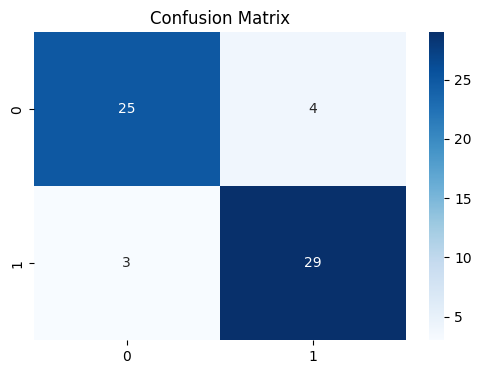

In [20]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title(
    "Confusion Matrix"
)
plt.show()

In [22]:
import joblib
joblib.dump(
    stack_model,
    "../models/stacking_classifier.pkl"
)
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)
joblib.dump(
    label_encoder,
    "../models/label_encoder.pkl"
)
joblib.dump(
    X.columns.tolist(),
    "../models/feature_names.pkl"
)
print("All Files Saved Successfully")

All Files Saved Successfully
